<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [5]:
import urllib.request
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv", "survey-data.csv")

('survey-data.csv', <http.client.HTTPMessage at 0x2383888f5c0>)

In [4]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [6]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: C:\Program Files\Python310\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: C:\Program Files\Python310\python.exe -m pip install --upgrade pip


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [7]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [8]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [9]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [10]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [11]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [12]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [13]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [14]:
QUERY = """
SELECT CompTotal FROM main
"""

df1 = pd.read_sql_query(QUERY, conn)

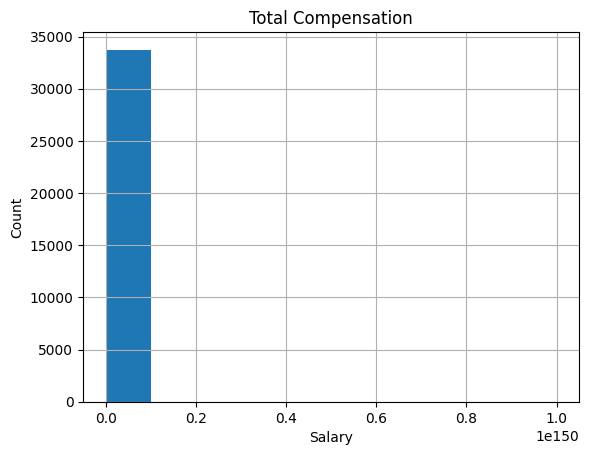

In [17]:
df1['CompTotal'].hist()
plt.title("Total Compensation")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

**Box Plots**

Plot a box plot of Age.


In [18]:
QUERY = """
SELECT Age FROM main
"""

df2 = pd.read_sql_query(QUERY, conn)

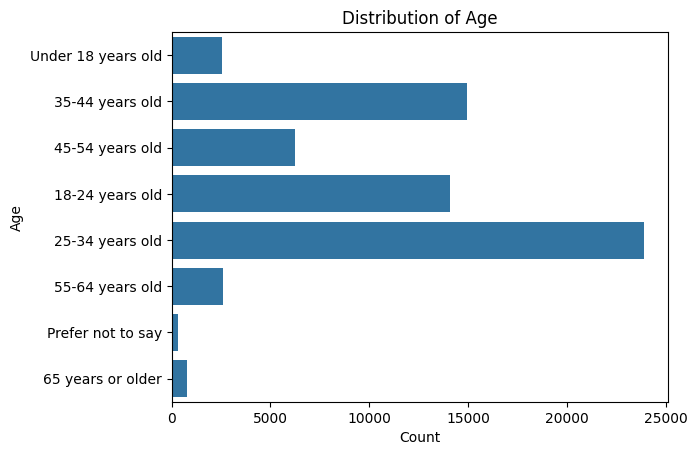

In [21]:
import seaborn as sns

sns.countplot(y='Age', data=df2)
plt.title("Distribution of Age")
plt.xlabel("Count")
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


In [22]:
QUERY = """
SELECT Age, WorkExp FROM main
"""

df3 = pd.read_sql_query(QUERY, conn)

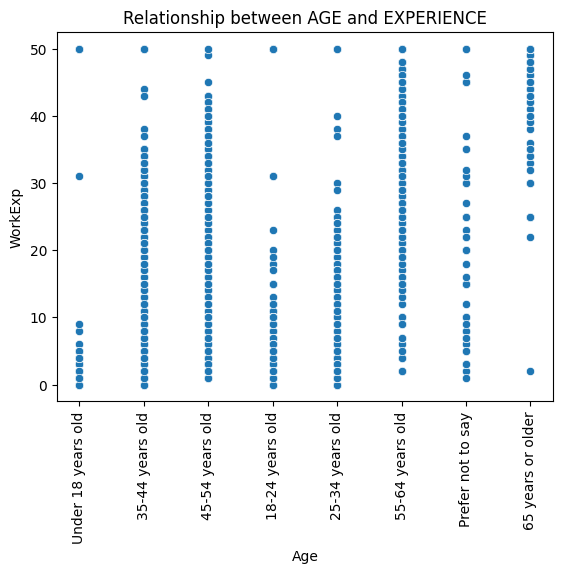

In [24]:
sns.scatterplot(x='Age', y='WorkExp', data=df3)
plt.title("Relationship between AGE and EXPERIENCE")
plt.xticks(rotation=90)
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [25]:
QUERY = """
SELECT TimeSearching, Frustration, Age FROM main
WHERE TimeSearching IS NOT NULL
AND Frustration IS NOT NULL
AND Age IS NOT NULL
"""

df4 = pd.read_sql_query(QUERY,conn)

In [26]:
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 25
}

df4['Age_numeric'] = df4['Age'].map(age_map)

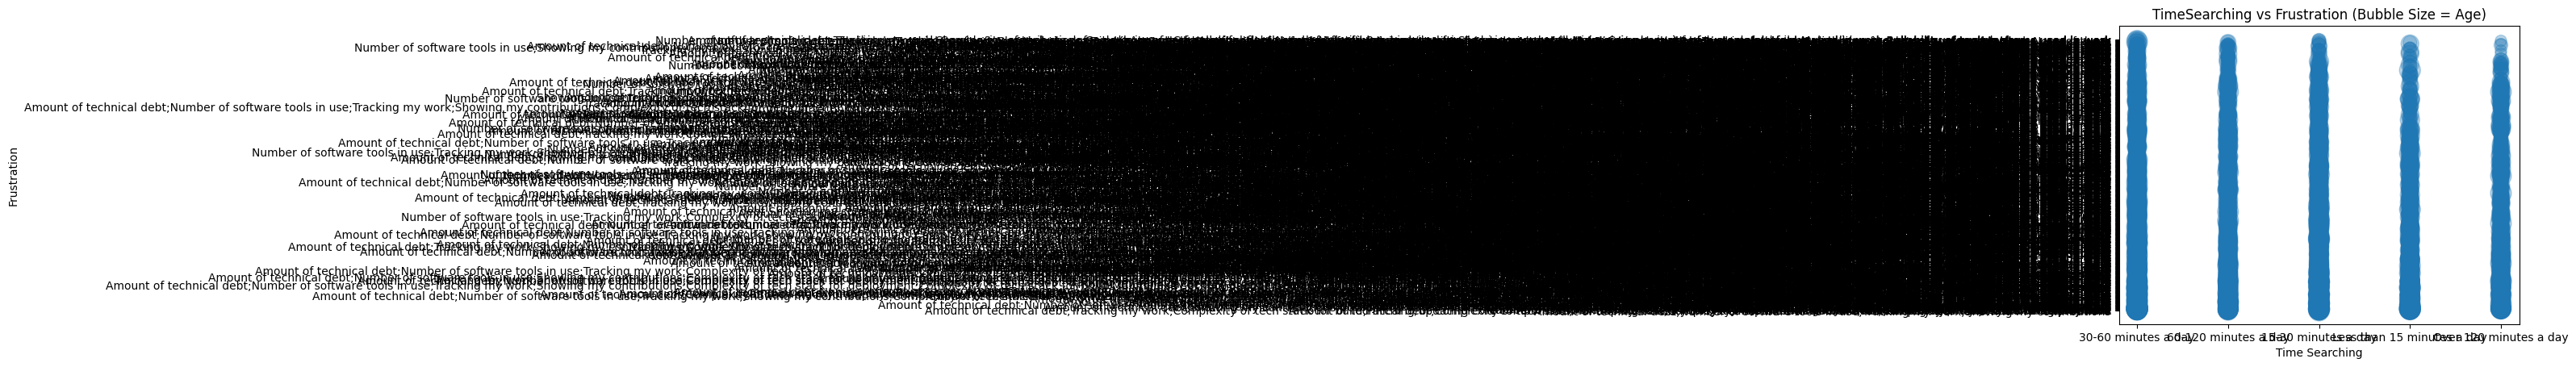

In [27]:
plt.scatter(x=df4['TimeSearching'], 
            y=df4['Frustration'], 
            s=df4['Age_numeric'] * 5, 
            alpha=0.3)
plt.title("TimeSearching vs Frustration (Bubble Size = Age)")
plt.xlabel("Time Searching")
plt.ylabel("Frustration")
plt.show()

In [28]:
print(df4['TimeSearching'].head(10))
print("---")
print(df4['Frustration'].head(10))

0           30-60 minutes a day
1           30-60 minutes a day
2          60-120 minutes a day
3           15-30 minutes a day
4    Less than 15 minutes a day
5          60-120 minutes a day
6           15-30 minutes a day
7           30-60 minutes a day
8          60-120 minutes a day
9          60-120 minutes a day
Name: TimeSearching, dtype: object
---
0    Amount of technical debt;Number of software to...
1    Amount of technical debt;Complexity of tech st...
2    Amount of technical debt;Complexity of tech st...
3    Amount of technical debt;Tracking my work;Comp...
4    Number of software tools in use;Tracking my wo...
5                             Amount of technical debt
6    Amount of technical debt;Number of software to...
7                                        None of these
8    Amount of technical debt;Number of software to...
9    Amount of technical debt;Tracking my work;Show...
Name: Frustration, dtype: object


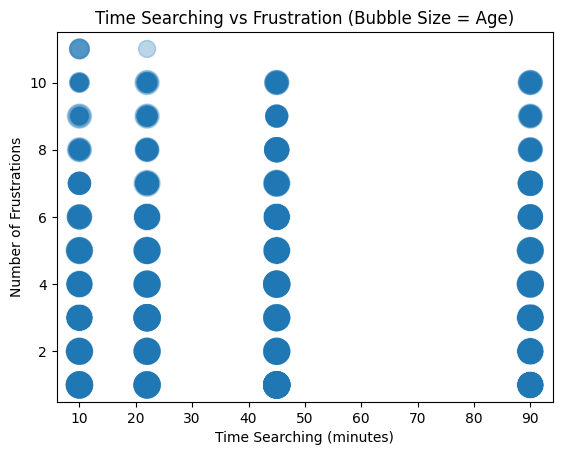

In [29]:
# Part 1: Get the data from the database
QUERY = """
SELECT TimeSearching, Frustration, Age FROM main
WHERE TimeSearching IS NOT NULL 
AND Frustration IS NOT NULL 
AND Age IS NOT NULL
"""
df4 = pd.read_sql_query(QUERY, conn)

# Part 2: Turn Age words into numbers
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 25
}
df4['Age_numeric'] = df4['Age'].map(age_map)

# Part 3: Turn TimeSearching words into numbers
time_map = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    '120+ minutes a day': 150
}
df4['TimeSearching_numeric'] = df4['TimeSearching'].map(time_map)

# Part 4: Count how many frustrations each person has
df4['Frustration_count'] = df4['Frustration'].str.count(';') + 1

# Part 5: Draw the bubble plot
plt.scatter(x=df4['TimeSearching_numeric'], 
            y=df4['Frustration_count'], 
            s=df4['Age_numeric'] * 5, 
            alpha=0.3)
plt.title("Time Searching vs Frustration (Bubble Size = Age)")
plt.xlabel("Time Searching (minutes)")
plt.ylabel("Number of Frustrations")
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


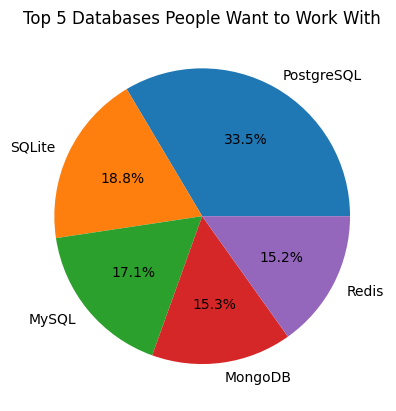

In [30]:
QUERY = """
SELECT DatabaseWantToWorkWith FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""

df5 = pd.read_sql_query(QUERY,conn)



all_databases = df5['DatabaseWantToWorkWith'].str.split(';').explode()

top5 = all_databases.value_counts().head(5)



top5.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Databases People Want to Work With")
plt.ylabel("")
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


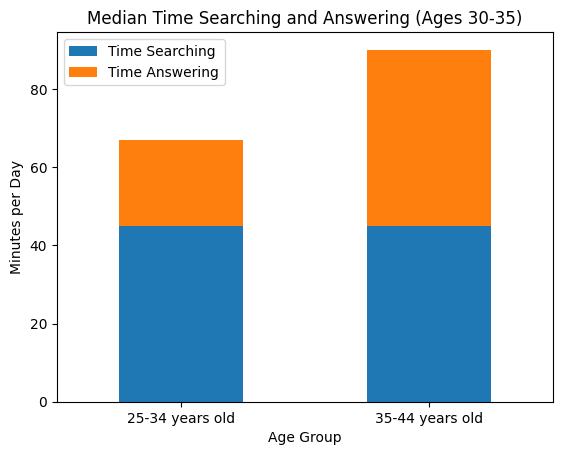

In [31]:
QUERY = """
SELECT Age, TimeSearching, TimeAnswering FROM main
WHERE TimeSearching IS NOT NULL
AND TimeAnswering IS NOT NULL
AND Age IS NOT NULL
"""

df6 = pd.read_sql_query(QUERY,conn)

time_search_map = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    '120+ minutes a day': 150
}
df6['TimeSearching_numeric'] = df6['TimeSearching'].map(time_search_map)


time_answer_map = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    '120+ minutes a day': 150
}
df6['TimeAnswering_numeric'] = df6['TimeAnswering'].map(time_answer_map)



df6_filtered = df6[df6['Age'].isin(['25-34 years old' , '35-44 years old'])]

medians = df6_filtered.groupby('Age')[['TimeSearching_numeric' , 'TimeAnswering_numeric']].median()



medians.plot(kind='bar', stacked=True)
plt.title("Median Time Searching and Answering (Ages 30-35)")
plt.xlabel("Age Group")
plt.ylabel("Minutes per Day")
plt.xticks(rotation=0)
plt.legend(['Time Searching', 'Time Answering'])
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


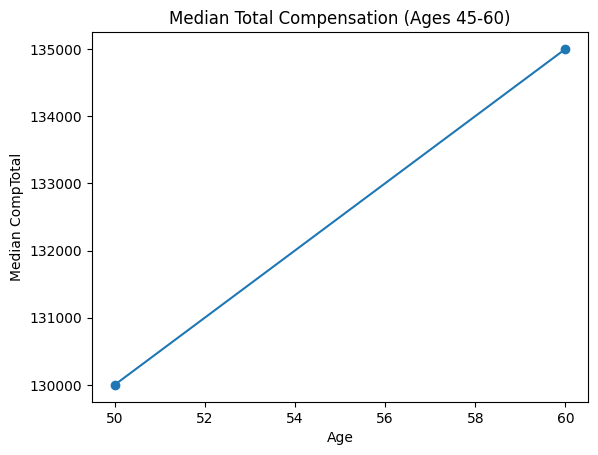

In [32]:
# Part 1: Get the data from the database
QUERY = """
SELECT Age, CompTotal FROM main
WHERE CompTotal IS NOT NULL
AND Age IS NOT NULL
"""
df7 = pd.read_sql_query(QUERY, conn)

# Part 2: Turn Age words into numbers
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 25
}
df7['Age_numeric'] = df7['Age'].map(age_map)

# Part 3: Filter for ages 45 to 60
df7_filtered = df7[(df7['Age_numeric'] >= 45) & (df7['Age_numeric'] <= 60)]

# Part 4: Calculate the median CompTotal for each age group
medians = df7_filtered.groupby('Age_numeric')['CompTotal'].median()

# Part 5: Draw the line chart
medians.plot(kind='line', marker='o')
plt.title("Median Total Compensation (Ages 45-60)")
plt.xlabel("Age")
plt.ylabel("Median CompTotal")
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


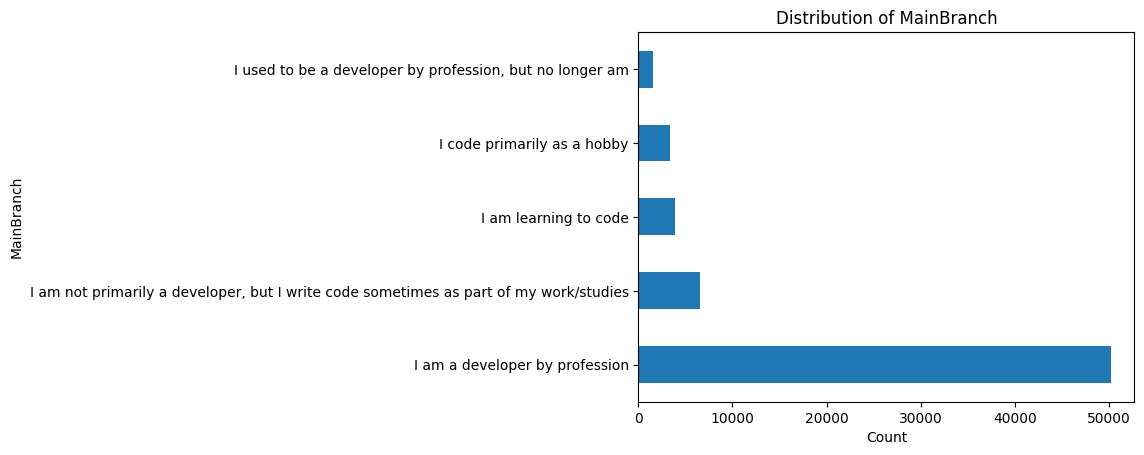

In [33]:
# Part 1: Get the data from the database
QUERY = """
SELECT MainBranch FROM main
WHERE MainBranch IS NOT NULL
"""
df8 = pd.read_sql_query(QUERY, conn)

# Part 2: Count how many people are in each category
counts = df8['MainBranch'].value_counts()

# Part 3: Draw the horizontal bar chart
counts.plot(kind='barh')
plt.title("Distribution of MainBranch")
plt.xlabel("Count")
plt.ylabel("MainBranch")
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [34]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
